# Сводный анализ сравнения моделей

Этот notebook является компактным аналитическим слоем для ВКР.

Что он делает:
- не переобучает модели;
- читает уже готовые артефакты из `experiments/model_comparison/`;
- показывает краткую схему comparison-контура;
- собирает benchmark, `search_summary` и operational snapshot-preview в одном месте.

Что он сознательно не делает:
- не дублирует preprocessing и EDA;
- не заменяет подробные логи и CSV-артефакты;
- не пытается пересказать весь проект целиком.


In [52]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def find_project_root(start: Path) -> Path:
    """Найти корень репозитория по маркерам проекта."""
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "Project root was not found. Expected README.md and pyproject.toml in parent directories."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUT_DIR = PROJECT_ROOT / "experiments" / "model_comparison"
BENCHMARK_RUN_NAME = "baseline_comparison_2026-03-13_vkr30_cv10"
SNAPSHOT_RUN_NAME = "baseline_comparison_2026-03-13_vkr30_cv10_limit5000"
TOP_K = 50
SNAPSHOT_LIMIT = 5000

MODEL_ORDER = [
    "main_contrastive_v1",
    "baseline_random_forest",
    "baseline_mlp_small",
    "baseline_legacy_gaussian",
]
MODEL_LABELS = {
    "main_contrastive_v1": "Contrastive V1",
    "baseline_random_forest": "RandomForest",
    "baseline_mlp_small": "MLP small",
    "baseline_legacy_gaussian": "Legacy Gaussian",
}
MODEL_FAMILY = {
    "main_contrastive_v1": "Основная contrastive Gaussian-модель",
    "baseline_random_forest": "Классический ML baseline",
    "baseline_mlp_small": "Компактный ИНС baseline",
    "baseline_legacy_gaussian": "Исторический Gaussian baseline",
}
MODEL_COLORS = {
    "main_contrastive_v1": "#1f77b4",
    "baseline_random_forest": "#2ca02c",
    "baseline_mlp_small": "#ff7f0e",
    "baseline_legacy_gaussian": "#7f7f7f",
}

summary_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_summary.csv"
classwise_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_classwise.csv"
search_summary_path = OUTPUT_DIR / f"{BENCHMARK_RUN_NAME}_search_summary.csv"
snapshot_summary_path = OUTPUT_DIR / f"{SNAPSHOT_RUN_NAME}_snapshot_summary.csv"
main_priority_path = OUTPUT_DIR / f"{SNAPSHOT_RUN_NAME}_snapshot_main_contrastive_v1_priority.csv"
top_paths = {
    model_name: OUTPUT_DIR / f"{SNAPSHOT_RUN_NAME}_snapshot_{model_name}_top.csv"
    for model_name in MODEL_ORDER
}

required_paths = [
    summary_path,
    classwise_path,
    search_summary_path,
    snapshot_summary_path,
    main_priority_path,
    *top_paths.values(),
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        "Comparison artifacts not found:\n"
        f"{missing_text}\n\n"
        "If artifacts were not generated yet, run:\n"
        f"  python {PROJECT_ROOT / 'src' / 'model_comparison.py'} --run-name {BENCHMARK_RUN_NAME}\n"
        f"  python {PROJECT_ROOT / 'src' / 'model_comparison.py'} --run-name {SNAPSHOT_RUN_NAME} --skip-snapshot"
    )

summary_df = pd.read_csv(summary_path, low_memory=False)
classwise_df = pd.read_csv(classwise_path, low_memory=False)
search_summary_df = pd.read_csv(search_summary_path, low_memory=False)
snapshot_summary_df = pd.read_csv(snapshot_summary_path, low_memory=False)
main_priority_df = pd.read_csv(main_priority_path, low_memory=False)

test_summary_df = (
    summary_df.loc[summary_df["split_name"] == "test"].copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
    .assign(model_family=lambda df: df["model_name"].map(MODEL_FAMILY))
)
test_summary_df["model_label"] = pd.Categorical(
    test_summary_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
test_summary_df = test_summary_df.sort_values("model_label").reset_index(drop=True)

classwise_test_df = (
    classwise_df.loc[classwise_df["split_name"] == "test"].copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
classwise_test_df["model_label"] = pd.Categorical(
    classwise_test_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
classwise_test_df = classwise_test_df.sort_values(["model_label", "spec_class"]).reset_index(drop=True)

search_summary_df = (
    search_summary_df.copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
    .assign(spec_class=lambda df: df["spec_class"].fillna("all"))
)
search_summary_df["model_label"] = pd.Categorical(
    search_summary_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
search_summary_df = search_summary_df.sort_values(["model_label", "search_scope", "spec_class"]).reset_index(drop=True)

snapshot_summary_df = (
    snapshot_summary_df.copy()
    .assign(model_label=lambda df: df["model_name"].map(MODEL_LABELS))
)
snapshot_summary_df["model_label"] = pd.Categorical(
    snapshot_summary_df["model_label"],
    categories=[MODEL_LABELS[name] for name in MODEL_ORDER],
    ordered=True,
)
snapshot_summary_df = snapshot_summary_df.sort_values("model_label").reset_index(drop=True)

top_frames = {
    model_name: pd.read_csv(path, low_memory=False)
    for model_name, path in top_paths.items()
}

snapshot_context = snapshot_summary_df.iloc[0][[
    "input_rows",
    "router_rows",
    "host_candidates",
    "low_known_rows",
    "unknown_rows",
]]

comparison_overview_df = (
    test_summary_df[
        ["model_name", "model_label", "model_family", "roc_auc", "pr_auc", "brier", "precision_at_k"]
    ]
    .merge(
        snapshot_summary_df[
            ["model_name", "high_rows", "medium_rows", "low_rows", "top_final_score"]
        ],
        on="model_name",
        how="left",
    )
)
comparison_overview_df

,model_name,model_label,model_family,roc_auc,pr_auc,brier,precision_at_k,high_rows,medium_rows,low_rows,top_final_score
0,main_contrastive_v1,Contrastive V1,Основная contrastive Gaussian-модель,0.867370,0.590399,0.154324,0.72,811,1379,2810,0.891755
1,baseline_random_forest,RandomForest,Классический ML baseline,0.932604,0.761796,0.090081,0.92,439,927,3634,0.814462
2,baseline_mlp_small,MLP small,Компактный ИНС baseline,0.922728,0.755534,0.090139,0.92,168,898,3934,0.793854
3,baseline_legacy_gaussian,Legacy Gaussian,Исторический Gaussian baseline,0.846410,0.571297,0.148316,0.72,18,868,4114,0.673218


## Упрощённая схема comparison-контура

Ниже показана именно логика сравнительного прогона моделей.

Идея такая:
- входной relation один и тот же;
- `router + OOD` общий;
- внутри host-ветки работают разные model head;
- downstream orchestrator общий для всех;
- дальше идёт единый аналитический слой.


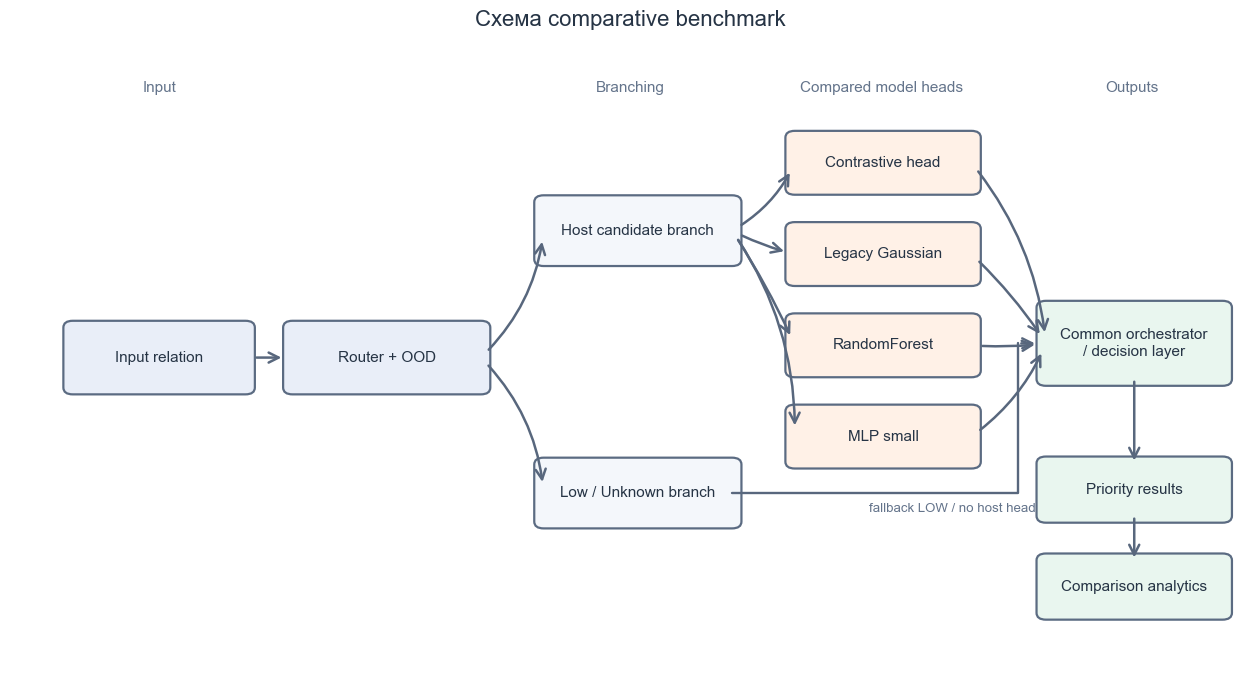

In [53]:
fig, ax = plt.subplots(figsize=(16, 8), facecolor="white")
ax.set_xlim(0, 15.8)
ax.set_ylim(0, 10.8)
ax.axis("off")

EDGE = "#5b6b82"
TEXT = "#263445"
ARROW = "#58677d"
PALETTE = {
    "input": "#e9eef8",
    "branch": "#f4f7fb",
    "head": "#fff1e7",
    "output": "#e9f6ef",
}

boxes = {
    "input": (0.8, 4.9, 2.2, 1.05, "Input relation", "input"),
    "router": (3.6, 4.9, 2.4, 1.05, "Router + OOD", "input"),
    "host": (6.8, 7.15, 2.4, 1.0, "Host candidate branch", "branch"),
    "low": (6.8, 2.55, 2.4, 1.0, "Low / Unknown branch", "branch"),
    "contrastive": (10.0, 8.4, 2.25, 0.88, "Contrastive head", "head"),
    "legacy": (10.0, 6.8, 2.25, 0.88, "Legacy Gaussian", "head"),
    "rf": (10.0, 5.2, 2.25, 0.88, "RandomForest", "head"),
    "mlp": (10.0, 3.6, 2.25, 0.88, "MLP small", "head"),
    "orchestrator": (13.2, 5.05, 2.25, 1.25, "Common orchestrator\n/ decision layer", "output"),
    "results": (13.2, 2.65, 2.25, 0.92, "Priority results", "output"),
    "analytics": (13.2, 0.95, 2.25, 0.92, "Comparison analytics", "output"),
}


def add_box(x, y, w, h, label, color_key):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.12,rounding_size=0.12",
        linewidth=1.6,
        edgecolor=EDGE,
        facecolor=PALETTE[color_key],
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        color=TEXT,
    )


for _, (x, y, w, h, label, color_key) in boxes.items():
    add_box(x, y, w, h, label, color_key)

ax.text(1.9, 10.15, "Input", ha="center", va="center", fontsize=11, color="#64748b")
ax.text(7.9, 10.15, "Branching", ha="center", va="center", fontsize=11, color="#64748b")
ax.text(11.1, 10.15, "Compared model heads", ha="center", va="center", fontsize=11, color="#64748b")
ax.text(14.3, 10.15, "Outputs", ha="center", va="center", fontsize=11, color="#64748b")



def mid_left(name):
    x, y, w, h, _, _ = boxes[name]
    return x, y + h / 2



def mid_right(name):
    x, y, w, h, _, _ = boxes[name]
    return x + w, y + h / 2



def connect(src, dst, rad=0.0, lw=1.8):
    ax.annotate(
        "",
        xy=mid_left(dst),
        xytext=mid_right(src),
        arrowprops=dict(
            arrowstyle="->",
            lw=lw,
            color=ARROW,
            shrinkA=8,
            shrinkB=8,
            connectionstyle=f"arc3,rad={rad}",
        ),
    )



def connect_routed(src, route_points, dst, lw=1.8):
    points = [mid_right(src), *route_points]
    xs, ys = zip(*points)
    ax.plot(xs, ys, color=ARROW, lw=lw, solid_capstyle="round")
    ax.annotate(
        "",
        xy=mid_left(dst),
        xytext=points[-1],
        arrowprops=dict(
            arrowstyle="->",
            lw=lw,
            color=ARROW,
            shrinkA=2,
            shrinkB=8,
        ),
    )


connect("input", "router")
connect("router", "host", rad=0.18)
connect("router", "low", rad=-0.18)

connect("host", "contrastive", rad=0.16)
connect("host", "legacy", rad=0.06)
connect("host", "rf", rad=-0.04)
connect("host", "mlp", rad=-0.16)

connect("contrastive", "orchestrator", rad=-0.15)
connect("legacy", "orchestrator", rad=-0.06)
connect("rf", "orchestrator", rad=0.05)
connect("mlp", "orchestrator", rad=0.14)
connect_routed(
    "low",
    [(9.55, 3.05), (12.85, 3.05), (12.85, 5.675)],
    "orchestrator",
    lw=1.7,
)

ax.text(10.95, 2.72, "fallback LOW / no host head", fontsize=9.5, color="#64748b")

ax.annotate(
    "",
    xy=(14.325, 3.57),
    xytext=(14.325, 5.05),
    arrowprops=dict(arrowstyle="->", lw=1.8, color=ARROW),
)
ax.annotate(
    "",
    xy=(14.325, 1.87),
    xytext=(14.325, 2.65),
    arrowprops=dict(arrowstyle="->", lw=1.8, color=ARROW),
)

ax.set_title("Схема comparative benchmark", fontsize=16, pad=18, color=TEXT)
plt.show()


## Что именно сравниваем

В notebook сравниваются четыре model head на одном и том же benchmark и
на одном и том же downstream orchestrator.

Для benchmark используется уже обновлённый ВКР-контракт:
- `test_size = 0.30`;
- `10-fold CV` внутри train split;
- отдельный `search_summary` с best params.


In [54]:
comparison_overview_df.rename(
    columns={
        "model_label": "Модель",
        "model_family": "Роль в работе",
        "roc_auc": "ROC-AUC (test)",
        "pr_auc": "PR-AUC (test)",
        "brier": "Brier (test)",
        "precision_at_k": "precision@50 (test)",
        "high_rows": "HIGH",
        "medium_rows": "MEDIUM",
        "low_rows": "LOW",
        "top_final_score": "top final score",
    }
)


,model_name,Модель,Роль в работе,ROC-AUC (test),PR-AUC (test),Brier (test),precision@50 (test),HIGH,MEDIUM,LOW,top final score
0,main_contrastive_v1,Contrastive V1,Основная contrastive Gaussian-модель,0.867370,0.590399,0.154324,0.72,811,1379,2810,0.891755
1,baseline_random_forest,RandomForest,Классический ML baseline,0.932604,0.761796,0.090081,0.92,439,927,3634,0.814462
2,baseline_mlp_small,MLP small,Компактный ИНС baseline,0.922728,0.755534,0.090139,0.92,168,898,3934,0.793854
3,baseline_legacy_gaussian,Legacy Gaussian,Исторический Gaussian baseline,0.846410,0.571297,0.148316,0.72,18,868,4114,0.673218


## Supervised benchmark

Здесь сравниваются численные test-метрики на задаче `host vs field`.

Важно: это уже не старая волна `baseline_comparison_2026-03-13_mlp`, а
обновлённый benchmark `baseline_comparison_2026-03-13_vkr30_cv10`.


In [55]:
method_contract_df = pd.DataFrame(
    [
        {"Параметр": "Benchmark run", "Значение": BENCHMARK_RUN_NAME},
        {"Параметр": "test_size", "Значение": "0.30"},
        {"Параметр": "cv_folds", "Значение": "10"},
        {"Параметр": "cv_random_state", "Значение": "42"},
        {"Параметр": "search_refit_metric", "Значение": "roc_auc"},
        {"Параметр": "precision@k", "Значение": str(TOP_K)},
        {"Параметр": "Snapshot preview run", "Значение": SNAPSHOT_RUN_NAME},
        {"Параметр": "snapshot_limit", "Значение": str(SNAPSHOT_LIMIT)},
    ]
)
method_contract_df

,Параметр,Значение
0,Benchmark run,baseline_comparison_2026-03-13_vkr30_cv10
1,test_size,0.30
2,cv_folds,10
3,cv_random_state,42
4,search_refit_metric,roc_auc
5,precision@k,50
6,Snapshot preview run,baseline_comparison_2026-03-13_vkr30_cv10_limi...
7,snapshot_limit,5000


In [56]:
benchmark_table = test_summary_df[
    ["model_label", "roc_auc", "pr_auc", "brier", "precision_at_k"]
].rename(
    columns={
        "model_label": "Модель",
        "roc_auc": "ROC-AUC",
        "pr_auc": "PR-AUC",
        "brier": "Brier",
        "precision_at_k": "precision@50",
    }
)
benchmark_table


,Модель,ROC-AUC,PR-AUC,Brier,precision@50
0,Contrastive V1,0.867370,0.590399,0.154324,0.72
1,RandomForest,0.932604,0.761796,0.090081,0.92
2,MLP small,0.922728,0.755534,0.090139,0.92
3,Legacy Gaussian,0.846410,0.571297,0.148316,0.72


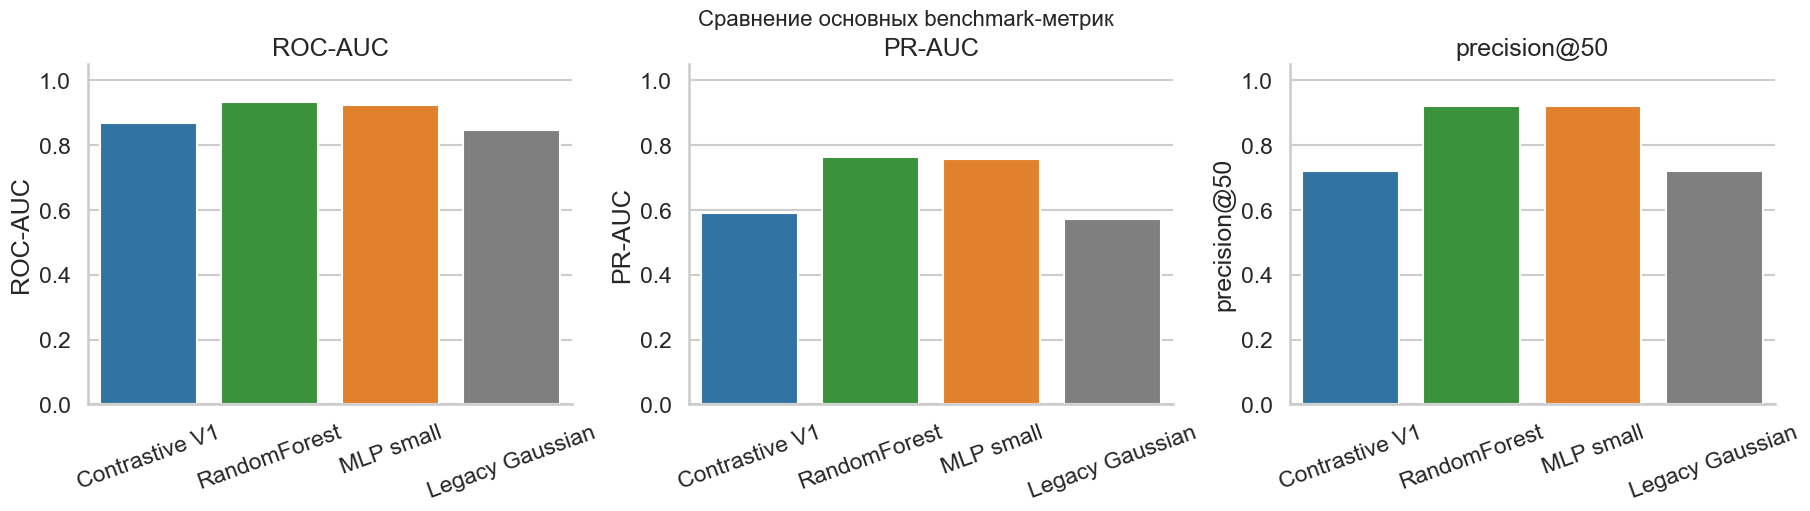

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
metric_specs = [
    ("roc_auc", "ROC-AUC"),
    ("pr_auc", "PR-AUC"),
    ("precision_at_k", "precision@50"),
]
for ax, (metric, title) in zip(axes, metric_specs):
    sns.barplot(
        data=test_summary_df,
        x="model_label",
        y=metric,
        hue="model_name",
        palette=MODEL_COLORS,
        dodge=False,
        ax=ax,
    )
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(0, 1.05)
fig.suptitle("Сравнение основных benchmark-метрик", fontsize=16)
plt.show()


## Search-контракт и выбранные параметры

С новой версией comparison-layer benchmark больше не ограничивается только
численными test-метриками. Теперь в notebook явно показано:
- что benchmark использует `test_size = 0.30`;
- что подбор параметров идёт через `10-fold CV` внутри train split;
- что для `RF/MLP` используется `GridSearchCV`, а для Gaussian-моделей —
  эквивалентный manual search;
- какие best params реально выбраны на новых артефактах.


In [58]:
search_summary_view_df = search_summary_df[
    [
        "model_label",
        "search_scope",
        "spec_class",
        "refit_metric",
        "cv_folds",
        "candidate_count",
        "best_cv_score",
        "best_params_json",
    ]
].rename(
    columns={
        "model_label": "Модель",
        "search_scope": "Масштаб поиска",
        "spec_class": "spec_class",
        "refit_metric": "Refit metric",
        "cv_folds": "CV folds",
        "candidate_count": "Число кандидатов",
        "best_cv_score": "Лучший CV score",
        "best_params_json": "best_params",
    }
)
search_summary_view_df

,Модель,Масштаб поиска,spec_class,Refit metric,CV folds,Число кандидатов,Лучший CV score,best_params
0,Contrastive V1,model,all,roc_auc,10,8,0.875410,"{""min_population_size"": 2, ""shrink_alpha"": 0.0..."
1,RandomForest,class,F,roc_auc,10,6,0.861399,"{""min_samples_leaf"": 4, ""n_estimators"": 300}"
2,RandomForest,class,G,roc_auc,10,6,0.902537,"{""min_samples_leaf"": 1, ""n_estimators"": 300}"
3,RandomForest,class,K,roc_auc,10,6,0.961211,"{""min_samples_leaf"": 4, ""n_estimators"": 100}"
4,RandomForest,class,M,roc_auc,10,6,0.923160,"{""min_samples_leaf"": 4, ""n_estimators"": 300}"
5,MLP small,class,F,roc_auc,10,6,0.737762,"{""alpha"": 0.01, ""hidden_layer_sizes"": [16, 8]}"
6,MLP small,class,G,roc_auc,10,6,0.904066,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [16, 8]}"
7,MLP small,class,K,roc_auc,10,6,0.960198,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [8, 4]}"
8,MLP small,class,M,roc_auc,10,6,0.904849,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [16, 8]}"
9,Legacy Gaussian,model,all,roc_auc,10,6,0.843709,"{""shrink_alpha"": 0.15, ""use_m_subclasses"": true}"


## Class-wise качество

Компактный heatmap показывает, как меняется качество на классах `M/K/G/F`.
Для summary-layer достаточно одного heatmap по `PR-AUC`.


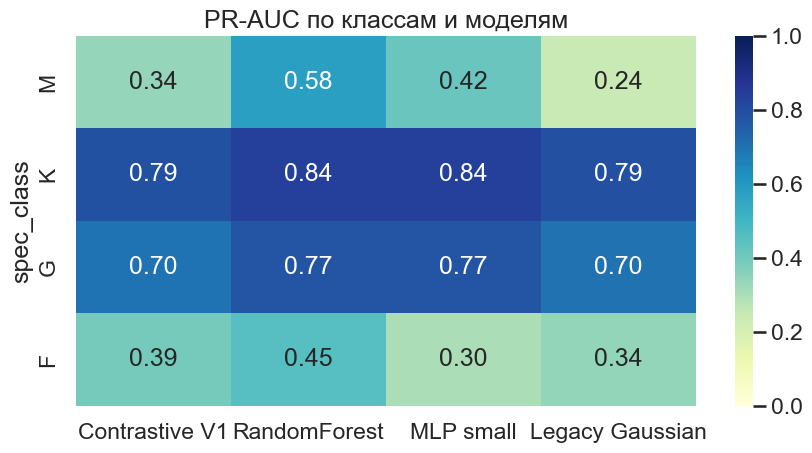

model_label,Contrastive V1,RandomForest,MLP small,Legacy Gaussian
spec_class,,,,
M,0.339432,0.575353,0.420101,0.244128
K,0.787895,0.839429,0.836176,0.790200
G,0.696463,0.774714,0.773902,0.701825
F,0.393108,0.454630,0.297167,0.340285


In [59]:
classwise_heatmap_df = (
    classwise_test_df.pivot(index="spec_class", columns="model_label", values="pr_auc")
    .reindex(index=["M", "K", "G", "F"])
    .reindex(columns=[MODEL_LABELS[name] for name in MODEL_ORDER])
)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    classwise_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    ax=ax,
)
ax.set_title("PR-AUC по классам и моделям")
ax.set_xlabel("")
ax.set_ylabel("spec_class")
plt.show()
classwise_heatmap_df


## Snapshot после общего оркестратора

Здесь уже показывается operational view: один и тот же `router + OOD`,
один и тот же downstream orchestrator, но разные model head внутри
host-ветки.

В текущей редакции notebook используется не полный relation, а
оперативный preview с `snapshot_limit = 5000`. Для ВКР это удобнее,
потому что он быстрее воспроизводится и даёт те же качественные выводы
по характеру ranking-а.


In [60]:
snapshot_context.to_frame(name="value")


,value
input_rows,5000
router_rows,5000
host_candidates,4202
low_known_rows,769
unknown_rows,29


In [61]:
snapshot_summary_df[
    ["model_label", "high_rows", "medium_rows", "low_rows", "top_final_score"]
].rename(
    columns={
        "model_label": "Модель",
        "high_rows": "HIGH",
        "medium_rows": "MEDIUM",
        "low_rows": "LOW",
        "top_final_score": "top final score",
    }
)


,Модель,HIGH,MEDIUM,LOW,top final score
0,Contrastive V1,811,1379,2810,0.891755
1,RandomForest,439,927,3634,0.814462
2,MLP small,168,898,3934,0.793854
3,Legacy Gaussian,18,868,4114,0.673218


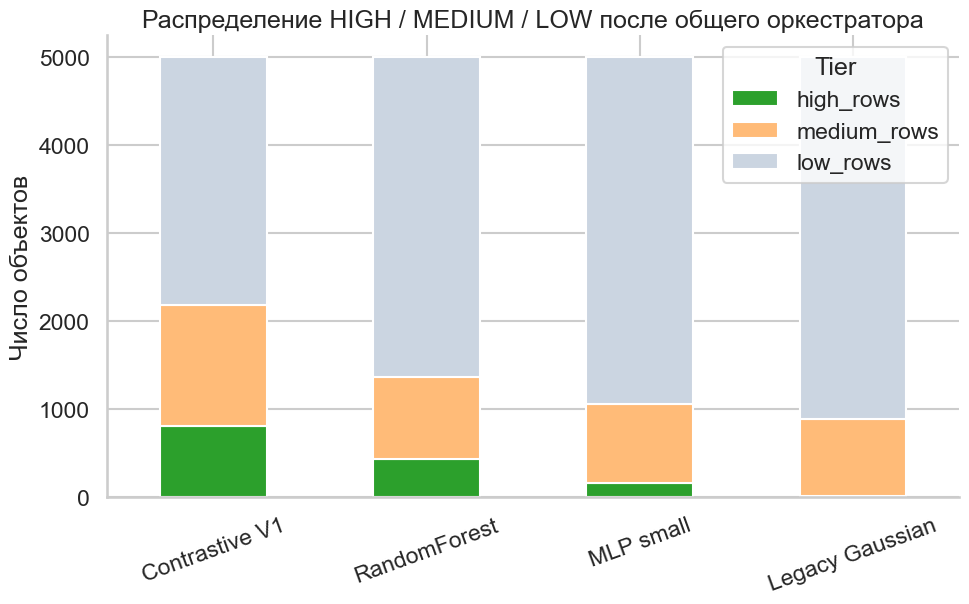

In [62]:
tier_plot_df = snapshot_summary_df[["model_label", "high_rows", "medium_rows", "low_rows"]].copy()
tier_plot_df = tier_plot_df.rename(columns={"model_label": "Модель"}).set_index("Модель")
fig, ax = plt.subplots(figsize=(11, 6))
tier_plot_df.plot(
    kind="bar",
    stacked=True,
    color=["#2ca02c", "#ffbb78", "#cbd5e1"],
    ax=ax,
)
ax.set_title("Распределение HIGH / MEDIUM / LOW после общего оркестратора")
ax.set_xlabel("")
ax.set_ylabel("Число объектов")
ax.legend(title="Tier")
ax.tick_params(axis="x", rotation=20)
plt.show()


## Согласие и расхождение моделей

В этом блоке оценивается, насколько модели совпадают по `top-k` после
общего оркестратора.

Такой срез особенно полезен для презентации: он показывает не только
"кто победил по ROC-AUC", но и где модели реально поддерживают одни и
те же follow-up кандидаты.


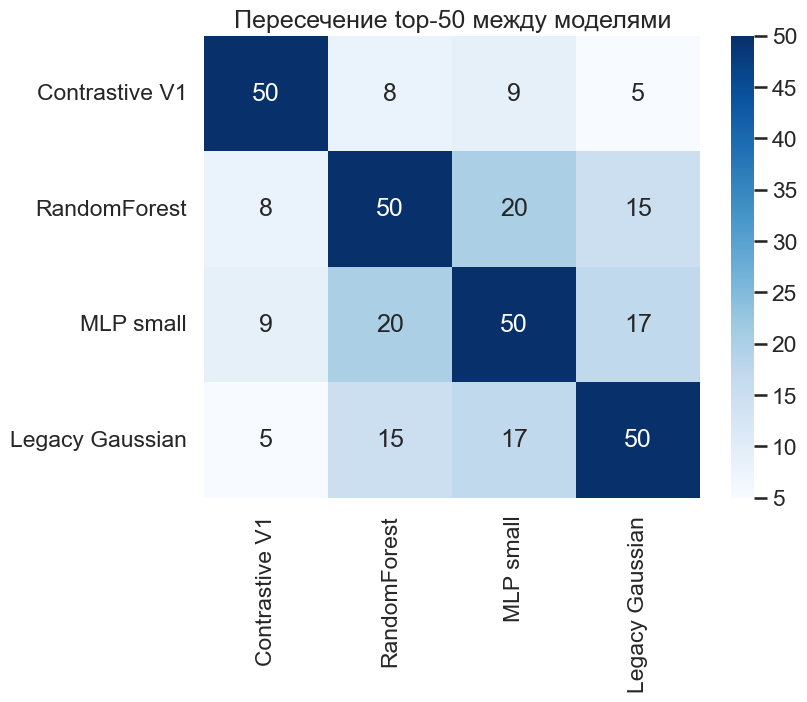

,Contrastive V1,RandomForest,MLP small,Legacy Gaussian
Contrastive V1,50.0,8.0,9.0,5.0
RandomForest,8.0,50.0,20.0,15.0
MLP small,9.0,20.0,50.0,17.0
Legacy Gaussian,5.0,15.0,17.0,50.0


In [63]:
overlap_matrix = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
for left_name in MODEL_ORDER:
    left_ids = set(top_frames[left_name]["source_id"].tolist())
    for right_name in MODEL_ORDER:
        right_ids = set(top_frames[right_name]["source_id"].tolist())
        overlap_matrix.loc[left_name, right_name] = len(left_ids & right_ids)

overlap_matrix = overlap_matrix.rename(index=MODEL_LABELS, columns=MODEL_LABELS)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title(f"Пересечение top-{TOP_K} между моделями")
plt.show()
overlap_matrix


In [64]:
support_rows = []
for model_name, top_df in top_frames.items():
    current = top_df[["source_id", "predicted_spec_class", "final_score"]].copy()
    current["model_name"] = model_name
    support_rows.append(current)

support_df = pd.concat(support_rows, ignore_index=True, sort=False)

def format_model_set(values: pd.Series) -> str:
    ordered = sorted(set(values), key=MODEL_ORDER.index)
    return ", ".join(MODEL_LABELS[name] for name in ordered)

disagreement_df = (
    support_df.groupby("source_id")
    .agg(
        spec_class=("predicted_spec_class", "first"),
        best_final_score=("final_score", "max"),
        n_models=("model_name", "nunique"),
        models=("model_name", format_model_set),
    )
    .reset_index()
)

unique_top_candidates_df = disagreement_df.loc[disagreement_df["n_models"] == 1].copy()
unique_top_candidates_df = unique_top_candidates_df.sort_values(
    ["best_final_score", "source_id"],
    ascending=[False, True],
    ignore_index=True,
).head(10)

consensus_top_candidates_df = disagreement_df.loc[disagreement_df["n_models"] >= 3].copy()
consensus_top_candidates_df = consensus_top_candidates_df.sort_values(
    ["n_models", "best_final_score"],
    ascending=[False, False],
    ignore_index=True,
).head(10)

examples_df = pd.concat(
    {
        "unique_top_candidates": unique_top_candidates_df,
        "consensus_top_candidates": consensus_top_candidates_df,
    },
    names=["section"],
)
examples_df


source_id spec_class  best_final_score  \
section                                                                        
unique_top_candidates    0   432750669838235648          M          0.891755   
                         1   342802853386881408          M          0.884584   
                         2   460225472553171840          M          0.872373   
                         3   257543659456732160          M          0.872118   
                         4   329380560894228736          M          0.866069   
                         5   632645972577236608          M          0.855951   
                         6   142224616488164096          M          0.836557   
                         7  1467945536018806144          M          0.830299   
                         8   395389226074355072          M          0.819111   
                         9   940039595155578240          M          0.812022   
consensus_top_candidates 0  1970498667200180352          K          0.814462   
                         1  1816493440755009536          K          0.805841   
                         2  1863187534912698624          K          0.785948   
                         3  2009812976760907136          K          0.776793   
                         4   422188486273959552          K          0.793854   
                         5  2068587783135629440          K          0.791883   
                         6  1865964622110670976          K          0.790137   
                         7   412783469966211456          K          0.784513   
                         8  2062037167754480640          K          0.783931   
                         9    59318278657519232          K          0.777293   

                            n_models  \
section                                
unique_top_candidates    0         1   
                         1         1   
                         2         1   
                         3         1   
                         4         1   
                         5         1   
                         6         1   
                         7         1   
                         8         1   
                         9         1   
consensus_top_candidates 0         4   
                         1         4   
                         2         4   
                         3         4   
                         4         3   
                         5         3   
                         6         3   
                         7         3   
                         8         3   
                         9         3   

                                                                       models  
section                                                                        
unique_top_candidates    0                                     Contrastive V1  
                         1                                     Contrastive V1  
                         2                                     Contrastive V1  
                         3                                     Contrastive V1  
                         4                                     Contrastive V1  
                         5                                     Contrastive V1  
                         6                                     Contrastive V1  
                         7                                     Contrastive V1  
                         8                                     Contrastive V1  
                         9                                     Contrastive V1  
consensus_top_candidates 0  Contrastive V1, RandomForest, MLP small, Legac...  
                         1  Contrastive V1, RandomForest, MLP small, Legac...  
                         2  Contrastive V1, RandomForest, MLP small, Legac...  
                         3  Contrastive V1, RandomForest, MLP small, Legac...  
                         4            Contrastive V1, RandomForest, MLP small  
                         5          

## Физический вывод

Важно: текущая система не доказывает наличие экзопланеты у конкретной
звезды. Она даёт физически согласованную приоритизацию объектов для
follow-up наблюдений.

В рамках текущей `V1` и обновлённого comparison-протокола итоговый
практический вывод такой:

1. **Первая очередь** — `K dwarf`.
   Это самая стабильная и массовая целевая популяция в `HIGH`-tier почти
   у всех моделей.
2. **Вторая очередь** — `M dwarf`.
   Именно `M`-карлики часто поднимаются в верхушку ranking у основной
   contrastive-модели, но класс остаётся более трудным и менее
   согласованным между моделями.
3. **Третья очередь** — `G dwarf`.
   Это рабочий, но менее приоритетный слой кандидатов по сравнению с
   `K` и верхушкой `M`.

Низкий приоритет в текущей конфигурации получают:
- горячие `A/B/O` звёзды;
- эволюционировавшие объекты;
- `unknown/OOD`-объекты;
- большая часть `F`-карликов как массовая follow-up популяция.


In [65]:
priority_conclusion_df = pd.DataFrame(
    [
        {
            "Очередь": 1,
            "Целевая популяция": "K dwarf",
            "Краткий смысл": "Наиболее стабильный и массовый HIGH-tier класс в итоговом ranking.",
        },
        {
            "Очередь": 2,
            "Целевая популяция": "M dwarf",
            "Краткий смысл": "Сильная зона для основной contrastive-модели, но с большей модельной неопределённостью.",
        },
        {
            "Очередь": 3,
            "Целевая популяция": "G dwarf",
            "Краткий смысл": "Рабочий слой кандидатов, уступающий K и верхушке M по итоговому приоритету.",
        },
    ]
)
priority_conclusion_df


,Очередь,Целевая популяция,Краткий смысл
0,1,K dwarf,Наиболее стабильный и массовый HIGH-tier класс...
1,2,M dwarf,"Сильная зона для основной contrastive-модели, ..."
2,3,G dwarf,"Рабочий слой кандидатов, уступающий K и верхуш..."


## Shortlist для follow-up наблюдений

Ниже собран простой прикладной shortlist без изменений в core pipeline.

Принцип формирования:
- берётся priority-result основной модели `main_contrastive_v1` из
  snapshot-preview `limit=5000`;
- в shortlist попадают только `HIGH`-кандидаты из целевых dwarf-классов;
- физический приоритет задаётся просто и прозрачно:
  - **приоритет 1** — `K dwarf`
  - **приоритет 2** — `M dwarf`
  - **приоритет 3** — `G dwarf`
- дополнительно показывается, сколько baseline-моделей поддержали объект в `top-50`.


In [66]:
priority_map = {"K": 1, "M": 2, "G": 3}

top_source_sets = {
    model_name: set(top_df["source_id"].astype(int).tolist())
    for model_name, top_df in top_frames.items()
}
all_shortlisted_source_ids = sorted(set().union(*top_source_sets.values()))
support_map = {
    source_id: [
        MODEL_LABELS[model_name]
        for model_name in MODEL_ORDER
        if source_id in top_source_sets.get(model_name, set())
    ]
    for source_id in all_shortlisted_source_ids
}

candidate_df = main_priority_df.loc[
    (main_priority_df["priority_tier"] == "HIGH")
    & (main_priority_df["predicted_evolution_stage"] == "dwarf")
    & (main_priority_df["predicted_spec_class"].isin(priority_map))
].copy()

candidate_df["source_id"] = candidate_df["source_id"].astype(int)
candidate_df["observation_priority"] = candidate_df["predicted_spec_class"].map(priority_map)
candidate_df["host_like_percent"] = (candidate_df["host_posterior"].astype(float) * 100.0).round(2)
candidate_df["host_like_profile"] = candidate_df["gauss_label"].fillna("-")
candidate_df["supported_models"] = candidate_df["source_id"].map(
    lambda source_id: support_map.get(int(source_id), [])
)
candidate_df["support_top50_count"] = candidate_df["supported_models"].map(len)
candidate_df["supported_by"] = candidate_df["supported_models"].map(
    lambda models: ", ".join(models) if models else "-"
)

shortlist_df = candidate_df.sort_values(
    ["observation_priority", "final_score", "host_posterior"],
    ascending=[True, False, False],
    ignore_index=True,
).copy()
shortlist_df["rank_in_priority"] = shortlist_df.groupby("observation_priority").cumcount() + 1

shortlist_view_df = shortlist_df[
    [
        "observation_priority",
        "rank_in_priority",
        "source_id",
        "ra",
        "dec",
        "predicted_spec_class",
        "predicted_evolution_stage",
        "host_like_percent",
        "host_like_profile",
        "final_score",
        "support_top50_count",
        "supported_by",
    ]
].rename(
    columns={
        "observation_priority": "Приоритет",
        "rank_in_priority": "Место в приоритете",
        "source_id": "source_id",
        "ra": "RA",
        "dec": "DEC",
        "predicted_spec_class": "Класс",
        "predicted_evolution_stage": "Стадия",
        "host_like_percent": "Похожесть на host, %",
        "host_like_profile": "Host-like профиль",
        "final_score": "Итоговый score",
        "support_top50_count": "Поддержка моделей (top-50)",
        "supported_by": "Поддержан моделями",
    }
)

shortlist_summary_df = shortlist_view_df.groupby("Приоритет").size().to_frame("Число кандидатов")
print("Shortlist по приоритетам:")
shortlist_summary_df


Shortlist по приоритетам:


,Число кандидатов
Приоритет,
1,635
2,174
3,2


In [67]:
shortlist_view_df.groupby("Приоритет", group_keys=False).head(10)


,Приоритет,Место в приоритете,source_id,RA,DEC,Класс,Стадия,"Похожесть на host, %",Host-like профиль,Итоговый score,Поддержка моделей (top-50),Поддержан моделями
0,1,1,412783469966211456,23.963734,56.698196,K,dwarf,94.27,K,0.784513,3,"Contrastive V1, RandomForest, MLP small"
1,1,2,2009812976760907136,344.801330,56.587310,K,dwarf,92.35,K,0.774973,4,"Contrastive V1, RandomForest, MLP small, Legac..."
2,1,3,1809920766401022976,304.031950,17.351519,K,dwarf,93.31,K,0.759360,2,"Contrastive V1, MLP small"
3,1,4,1795675321939484544,330.352570,24.789967,K,dwarf,90.23,K,0.757152,2,"Contrastive V1, RandomForest"
4,1,5,422188486273959552,5.232885,58.497204,K,dwarf,89.77,K,0.753312,3,"Contrastive V1, RandomForest, MLP small"
5,1,6,1863187534912698624,309.686160,33.064037,K,dwarf,89.54,K,0.751381,4,"Contrastive V1, RandomForest, MLP small, Legac..."
6,1,7,273059215932817280,72.406710,53.359220,K,dwarf,93.93,K,0.748785,1,Contrastive V1
7,1,8,1970498667200180352,321.505430,43.241745,K,dwarf,89.23,K,0.748750,4,"Contrastive V1, RandomForest, MLP small, Legac..."
8,1,9,532111783299089152,22.631739,68.966200,K,dwarf,93.80,K,0.747794,1,Contrastive V1
9,1,10,2012757194023841920,357.680450,61.575317,K,dwarf,93.60,K,0.746159,2,"Contrastive V1, Legacy Gaussian"


## Краткий вывод

Этот notebook не подменяет подробные документы, а даёт сжатый и
визуально понятный итог по comparison-layer.

В новой версии он уже согласован с текущим protocol:
- benchmark `30% + 10-fold CV + search summary`;
- snapshot-preview `limit=5000`;
- выводы, пригодные и для записки, и для будущих слайдов.


In [68]:
best_benchmark_row = test_summary_df.sort_values("roc_auc", ascending=False).iloc[0]
second_benchmark_row = test_summary_df.sort_values("roc_auc", ascending=False).iloc[1]
widest_snapshot_row = snapshot_summary_df.sort_values("high_rows", ascending=False).iloc[0]
most_conservative_row = snapshot_summary_df.sort_values("high_rows", ascending=True).iloc[0]
contrastive_search_row = search_summary_df.loc[search_summary_df["model_name"] == "main_contrastive_v1"].iloc[0]

print("1. Лучший benchmark по ROC-AUC:", MODEL_LABELS[best_benchmark_row["model_name"]])
print("2. Второй benchmark-результат:", MODEL_LABELS[second_benchmark_row["model_name"]])
print("3. Самый широкий operational ranking (limit=5000):", MODEL_LABELS[widest_snapshot_row["model_name"]])
print("4. Самый консервативный snapshot-поток (limit=5000):", MODEL_LABELS[most_conservative_row["model_name"]])
print("5. Лучшая конфигурация contrastive search:", contrastive_search_row["best_params_json"])
print("6. Benchmark и snapshot снова показывают, что сильная численная модель не обязана давать самый насыщенный итоговый ranking.")

1. Лучший benchmark по ROC-AUC: RandomForest
2. Второй benchmark-результат: MLP small
3. Самый широкий operational ranking (limit=5000): Contrastive V1
4. Самый консервативный snapshot-поток (limit=5000): Legacy Gaussian
5. Лучшая конфигурация contrastive search: {"min_population_size": 2, "shrink_alpha": 0.05, "use_m_subclasses": false}
6. Benchmark и snapshot снова показывают, что сильная численная модель не обязана давать самый насыщенный итоговый ranking.
